## Crude Oil Price Formation under Multiple Market Makers

This project study the impact of microstructure on price formation. The central question is: how do market makers, through their inventory management and quoting strategy, collectively shape the observed mid price of an asset?

We model this using the Avellaneda-Stoikov (2008) optimal market-making framework, running a Monte Carlo simulation over historical Brent and WTI Crude oil price.

### 1. Quoting Model

In Avellaneda-Stoikov model, the optimal symmetric half-spread around the mid is:

$$\delta^* = \frac{\gamma \cdot \sigma^2 \cdot T}{2}$$

This is the base half-spread it widens with volatility and risk aversion, and compresses with shorter horizons. We extend the base model with an exponential inventory skew that displaces the mid asymmetrically:

$$
s(q) = \frac{e^{k \cdot |q|/100} - 1}{e^k - 1}, \quad k = \max\!\left(2 + 8(1 - \sigma),\; 0.1\right)
$$

where $k$ modulates the sensitivity of the skew to inventory. High volatility regimes compress $k$, reducing skew aggressiveness. This gives final quotes:

$$
\text{bid} = S \cdot \left(1 - \delta^* - s(q)\cdot\delta^*\right)
$$
$$
\text{ask} = S \cdot \left(1 + \delta^* - s(q)\cdot\delta^*\right)
$$

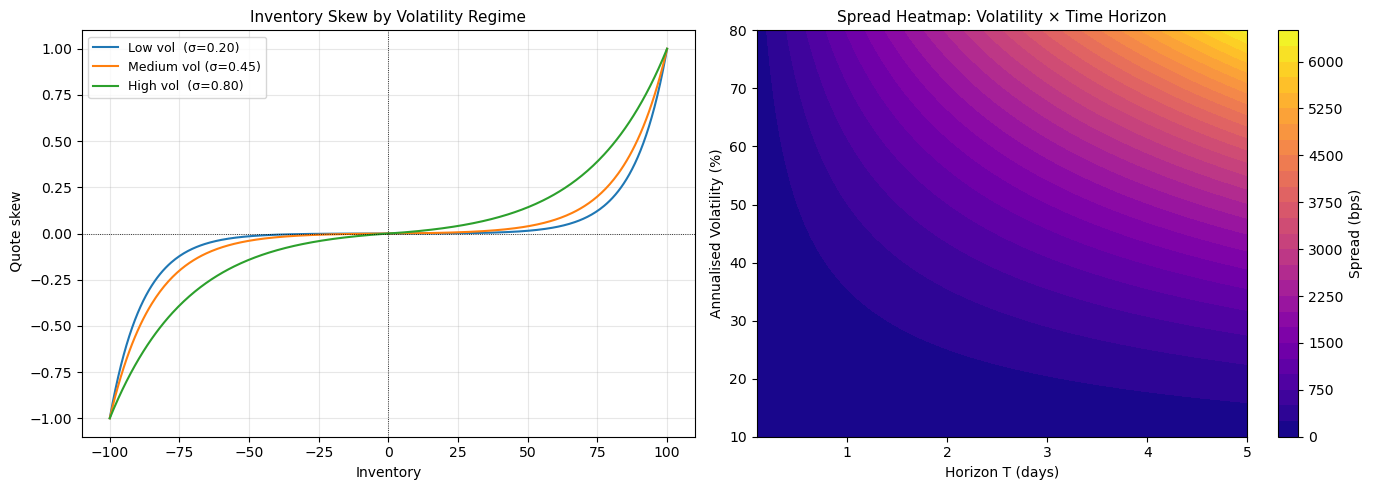

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Params
gamma = 50.0

# Inventory Skew
def skew(q, sigma):
    k = max(2.0 + 8.0 * (1.0 - sigma), 0.1)
    if q == 0:
        return 0.0
    exp_factor = (np.exp(k * abs(q) / 100) - 1) / (np.exp(k) - 1)
    return np.sign(q) * exp_factor

inventories = np.linspace(-100, 100, 400)
sigma_cases = {"Low vol  (σ=0.20)": 0.20, "Medium vol (σ=0.45)": 0.45, "High vol  (σ=0.80)": 0.80}

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot
ax = axes[0]
for label, s in sigma_cases.items():
    phi = [skew(q, s) for q in inventories]
    ax.plot(inventories, phi, label=label)
ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
ax.axvline(0, color="black", linewidth=0.6, linestyle=":")
ax.set_title(r"Inventory Skew by Volatility Regime", fontsize=11)
ax.set_xlabel("Inventory")
ax.set_ylabel(r" Quote skew")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right plot
T_grid   = np.linspace(0.1, 5.0, 100)
sig_grid = np.linspace(0.10, 0.80, 100)
TT, SS   = np.meshgrid(T_grid, sig_grid)
spread_map = gamma * (SS / np.sqrt(252))**2 * TT * 10_000
ax2 = axes[1]
cmap = ax2.contourf(TT, SS * 100, spread_map, levels=30, cmap="plasma")
fig.colorbar(cmap, ax=ax2, label="Spread (bps)")
ax2.set_title("Spread Heatmap: Volatility × Time Horizon", fontsize=11)
ax2.set_xlabel("Horizon T (days)")
ax2.set_ylabel("Annualised Volatility (%)")

plt.tight_layout()
plt.show()


### 2. Quote Calculator

Enter your own parameters below to compute bid, ask, spread and skew for a single market-maker quote.

In [22]:
from src.quotes import avellaneda_stoikov

# Enter your params:
mid  = 82.50    
sigma      = 0.40    
inventory  = 45.0     
gamma      = 50.0    
T          = 1.0
# ─────────────────────────────────────────────────────────────────────────
quotes = avellaneda_stoikov(mid, inventory, sigma, gamma, T)

print(f"  Ask            : ${quotes["ask"]:.2f}")
print(f"  Mid            : ${quotes["mid"]:.2f}")
print(f"  Bid            : ${quotes["bid"]:.2f}")
print(f"  Spread         : {quotes["spread_bps"]:.2f} bps")
print(f"  Effective mid  : ${((quotes["ask"] + quotes["bid"]) / 2):.2f}  ({(((quotes["ask"] + quotes["bid"]) / 2) - quotes["mid"])/quotes["mid"]*10000:+.1f} bps vs. obs)")
print(f"  Inventory skew : {quotes["skew_pct"] * 100:+.1f}%")

  Ask            : $83.78
  Mid            : $82.50
  Bid            : $81.16
  Spread         : 317.46 bps
  Effective mid  : $82.47  (-3.6 bps vs. obs)
  Inventory skew : +226.7%
